# Imports

In [243]:
import torch 
from torch import nn
from torch import optim
from torch.utils.data import DataLoader
from torch.utils.data import Dataset


import copy
from itertools import zip_longest

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.linear_model import Ridge
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, ndcg_score, average_precision_score
from sklearn.metrics import mean_squared_error

from collections import defaultdict



# Data Cleaning and EDA

In [164]:
# movies: movieId,title,genres
movies = pd.read_csv('/Users/gracefujinaga/MSDS_490/Data/grouplense_smallest/movies.csv')

# ratings: userId,movieId,rating,timestamp
ratings = pd.read_csv('/Users/gracefujinaga/MSDS_490/Data/grouplense_smallest/ratings.csv')

# tags: userId,movieId,tag,timestamp


In [7]:
movies.head(5)

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


In [165]:
ratings.head(5)

,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931


In [166]:
# merge dataframes
ratings = ratings.merge(movies[["movieId", "title"]], on="movieId")
ratings.head()

,userId,movieId,rating,timestamp,title
0,1,1,4.0,964982703,Toy Story (1995)
1,5,1,4.0,847434962,Toy Story (1995)
2,7,1,4.5,1106635946,Toy Story (1995)
3,15,1,2.5,1510577970,Toy Story (1995)
4,17,1,4.5,1305696483,Toy Story (1995)


In [12]:
min, max = ratings.rating.min(), ratings.rating.max()

In [35]:
print(f"min rating: {min}, max rating: {max}")
print(f"average rating: {ratings.rating.mean():.4f}")

min rating: 0.5, max rating: 5.0
average rating: 3.5016


### Average number of ratings per user

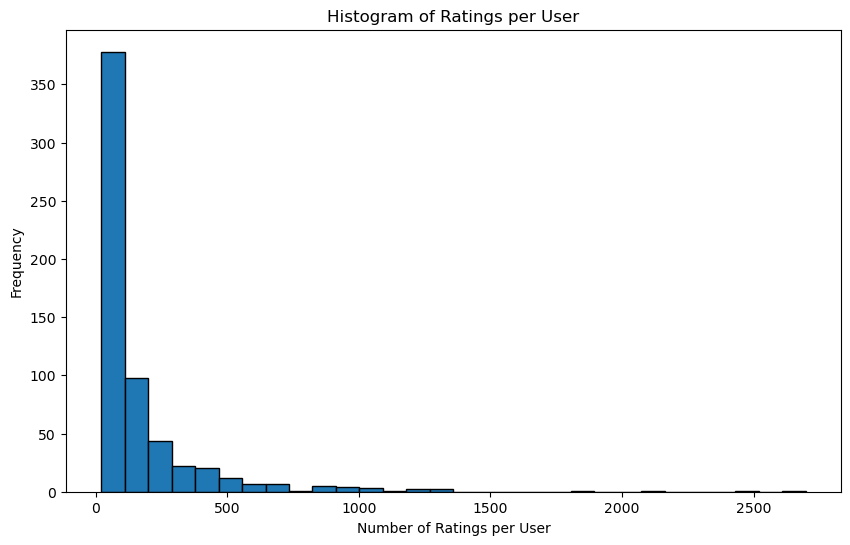

In [55]:
# group
user_grouped_df = ratings.groupby('userId')['movieId'].count().reset_index(name='Count')
user_grouped_df

# plot
plt.figure(figsize=(10,6))
plt.hist(user_grouped_df['Count'], bins=30, edgecolor='black')
plt.title('Histogram of Ratings per User')
plt.xlabel('Number of Ratings per User')
plt.ylabel('Frequency')
plt.show()

### Ratings per Movie

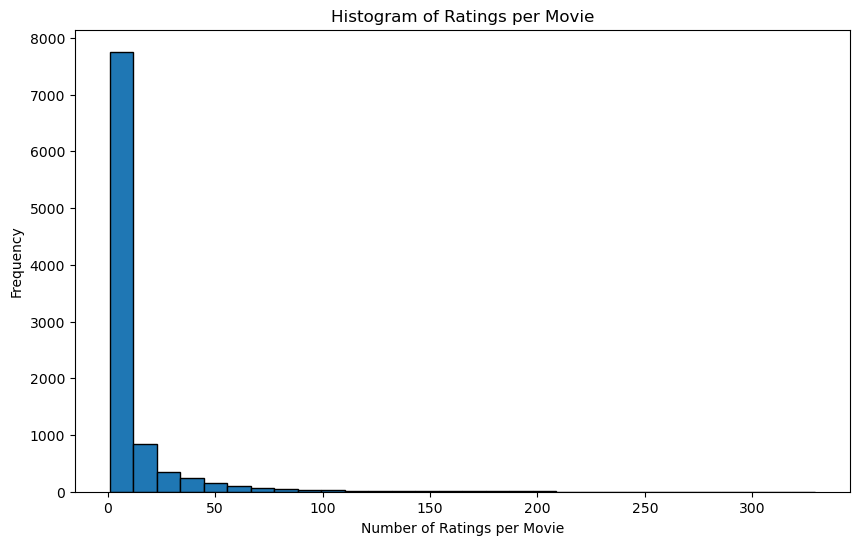

In [56]:
# group
user_grouped_df = ratings.groupby('movieId')['userId'].count().reset_index(name='Count')
user_grouped_df

# plot
plt.figure(figsize=(10,6))
plt.hist(user_grouped_df['Count'], bins=30, edgecolor='black')
plt.title('Histogram of Ratings per Movie')
plt.xlabel('Number of Ratings per Movie')
plt.ylabel('Frequency')
plt.show()

# Model

## Create Dataset and Split Data

In [179]:
# set up user to index mapping
unique_users = ratings.userId.unique()
user_to_index = {old: new for new, old in enumerate(unique_users)}
new_users = ratings.userId.map(user_to_index)

# set up movie to index mapping
unique_movies = ratings.movieId.unique()
movie_to_index = {old: new for new, old in enumerate(unique_movies)}
new_movies = ratings.movieId.map(movie_to_index)

# get num users
n_users = len(unique_users)
n_movies = len(unique_movies)
    
X = pd.DataFrame({'user_id': new_users, 'movie_id': new_movies})
y = ratings['rating'].astype(np.float32)


In [76]:
print(f'{n_users} users, {n_movies} movies')
print(f'Dataset shape: {X.shape}')
print(f'Target shape: {y.shape}')

610 users, 9724 movies
Dataset shape: (100836, 2)
Target shape: (100836,)


In [25]:
# split the data
X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.2, random_state=1)

## EmbeddingNet

In [124]:

class EmbeddingNet(nn.Module):
    def __init__(self, n_users, n_movies, n_factors=50, embedding_dropout=0.02, hidden=10, dropouts=0.2):
        super().__init__()

        # Embeddings
        self.user_embedding = nn.Embedding(n_users, n_factors)
        self.movie_embedding = nn.Embedding(n_movies, n_factors)
        self.embedding_dropout = nn.Dropout(embedding_dropout)

        # Hidden layers
        layers = []
        input_dim = 2 * n_factors
        for h, d in zip_longest(hidden, dropouts):
            layers.append(nn.Linear(input_dim, h))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(d))
            input_dim = h
        
        # Write the layers
        self.hidden_layers = nn.Sequential(*layers)

        # Output
        self.output_layer = nn.Linear(hidden[-1], 1)

        # Initialize weights
        nn.init.uniform_(self.user_embedding.weight, -0.05, 0.05)
        nn.init.uniform_(self.movie_embedding.weight, -0.05, 0.05)

        # # linear layers initialize weights
        # this addition of weights is KEY in getting better results
        def init_linear(m):
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                nn.init.constant_(m.bias, 0.01)

        self.hidden_layers.apply(init_linear)
        init_linear(self.output_layer)


    def forward(self, users, movies, minmax=None):
        # get the dense vectors for users and movies
        user_vec = self.user_embedding(users)
        movie_vec = self.movie_embedding(movies)

        # concatenate the vectors
        x = torch.cat([user_vec, movie_vec], dim=1)
        
        # add layers
        x = self.embedding_dropout(x)
        x = self.hidden_layers(x)

        # output with sigmoid function
        out = torch.sigmoid(self.output_layer(x))

        # add min and max 
        min_rating, max_rating = minmax
        out = out * (max_rating - min_rating + 1) + min_rating - 0.5
        return out


In [125]:

net = EmbeddingNet(
    n_users=n_users, 
    n_movies=n_movies, 
    n_factors=150, 
    hidden=[500, 500, 500], 
    embedding_dropout=0.05, 
    dropouts=[0.5, 0.5, 0.25])

## Training Loop 

In [113]:
# set up the ratings dataset class to use dataloader

class RatingsDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.LongTensor(np.array(X))
        self.y = torch.FloatTensor(np.array(y)).view(-1, 1)  # shape [N, 1]

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


In [119]:
bs = 200 

train_loader = DataLoader(RatingsDataset(X_train, y_train), batch_size=bs, shuffle=True)
valid_loader = DataLoader(RatingsDataset(X_valid, y_valid), batch_size=bs, shuffle=False)

dataloaders = {'train': train_loader, 'val': valid_loader}
dataset_sizes = {'train': len(X_train), 'val': len(X_valid)}


In [259]:
####### HYPERPARAMETERS ####
# first run:
#lr = 1e-5

#second run:
lr = 1e-3 
wd =1e-5

n_epochs = 200
patience = 10
##############################

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
net.to(device)

# mse loss and Adam optimizer
criterion = nn.MSELoss(reduction='sum')
optimizer = optim.Adam(net.parameters(), lr=lr, weight_decay=wd)

no_improvements = 0
best_loss = float('inf')
best_weights = None
history = []

for epoch in range(n_epochs):
    stats = {'epoch': epoch + 1, 'total': n_epochs}

    for phase in ('train', 'val'):
        training = (phase == 'train')
        if training: 
            net.train()
        else:
            net.eval()
        
        running_loss = 0.0

        for xb, yb in dataloaders[phase]:
            xb, yb = xb.to(device), yb.to(device)

            optimizer.zero_grad()
            with torch.set_grad_enabled(training):
                preds = net(xb[:, 0], xb[:, 1], (min, max))
                loss = criterion(preds, yb)
                if training:
                    loss.backward()
                    optimizer.step()
            running_loss += loss.item()

        epoch_loss = running_loss / dataset_sizes[phase]
        stats[phase] = epoch_loss

        if phase == 'val':
            if epoch_loss < best_loss:
                best_loss = epoch_loss
                best_weights = copy.deepcopy(net.state_dict())
                no_improvements = 0
            else:
                no_improvements += 1

    history.append(stats)
    print('[{epoch:03d}/{total:03d}] train: {train:.4f}, val: {val:.4f}'.format(**stats))
    
    if no_improvements >= patience:
        print(f'Early stopping on epoch {epoch+1}')
        break

# Load best weights after training
net.load_state_dict(best_weights)


[001/200] train: 0.7943, val: 0.7581
[002/200] train: 0.6975, val: 0.7485
[003/200] train: 0.6473, val: 0.7475
[004/200] train: 0.6000, val: 0.7541
[005/200] train: 0.5486, val: 0.7613
[006/200] train: 0.4944, val: 0.7610
[007/200] train: 0.4433, val: 0.7773
[008/200] train: 0.4023, val: 0.7808
[009/200] train: 0.3674, val: 0.7944
[010/200] train: 0.3416, val: 0.7851
[011/200] train: 0.3176, val: 0.8103
[012/200] train: 0.2992, val: 0.8079
[013/200] train: 0.2848, val: 0.8058
Early stopping on epoch 13


<All keys matched successfully>

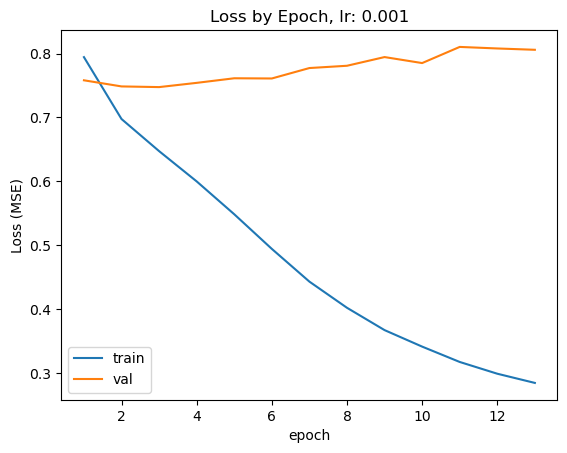

In [267]:
ax = pd.DataFrame(history).drop(columns='total').plot(x='epoch')
ax.set_title(f'Loss by Epoch, lr: {lr}')
ax.set_ylabel('Loss (MSE)')  
plt.show()

## Metrics

In [261]:
# predict all results

net.load_state_dict(best_weights)
net.eval()  # Set to evaluation mode

X_test_tensor = torch.LongTensor(np.array(X_valid)).to(device)

with torch.no_grad():
    y_pred = net(X_test_tensor[:, 0], X_test_tensor[:, 1], (min, max))
    y_pred = y_pred.cpu().numpy().flatten() 

final_loss = np.sqrt(np.mean((np.array(y_pred) - np.array(y_valid))**2))
print(f'Final RMSE: {final_loss:.4f}')

Final RMSE: 0.8646


In [262]:
results_df = X_valid.copy()
results_df['actual_rating'] = y_valid
results_df.rename(columns={'user_id' : 'userId'}, inplace=True)
results_df['predicted_rating'] = y_pred
results_df

,userId,movie_id,actual_rating,predicted_rating
67037,341,1891,4.0,3.586013
42175,83,907,2.0,3.042217
93850,106,5749,4.0,3.063159
6187,146,61,5.0,4.114348
12229,267,154,4.0,3.313479
...,...,...,...,...
57416,102,1378,3.5,3.990455
67290,83,1898,3.0,3.260568
33423,157,696,4.0,3.884946
98552,154,7775,0.5,2.543090


In [263]:
def precision_at_k_df(df, k=10, threshold=2.5):
    user_est_true = defaultdict(list)

    # Collect predictions per user
    for _, row in df.iterrows():
        uid = row['userId']
        pred = row['predicted_rating']
        actual = row['actual_rating']
        user_est_true[uid].append((pred, actual))

    precisions = dict()
    for uid, user_ratings in user_est_true.items():
        # Sort ratings by predicted score
        user_ratings.sort(key=lambda x: x[0], reverse=True)

        # Top-K items
        top_k = user_ratings[:k]

        # Count how many of top-k are relevant
        n_rec_k = sum(est >= threshold for est, _ in top_k)
        n_rel_and_rec_k = sum((est >= threshold and true_r >= threshold) for est, true_r in top_k)

        precisions[uid] = n_rel_and_rec_k / n_rec_k if n_rec_k != 0 else 0

    return precisions


def recall_at_k_df(df, k=10, threshold=2.5):
    user_est_true = defaultdict(list)

    # Collect predictions per user
    for _, row in df.iterrows():
        uid = row['userId']
        pred = row['predicted_rating']
        actual = row['actual_rating']
        user_est_true[uid].append((pred, actual))

    recalls = dict()
    for uid, user_ratings in user_est_true.items():
        user_ratings.sort(key=lambda x: x[0], reverse=True)
        top_k = user_ratings[:k]

        n_rel = sum(true_r >= threshold for _, true_r in user_ratings)
        n_rel_and_rec_k = sum((est >= threshold and true_r >= threshold) for est, true_r in top_k)

        recalls[uid] = n_rel_and_rec_k / n_rel if n_rel != 0 else 0

    return recalls


In [264]:
def prediction_metrics(predictions_df):
    # precision @k 
    precisions = precision_at_k_df(predictions_df, k=10, threshold=2.5)
    prec_at_k = sum(prec for prec in precisions.values()) / len(precisions)
    print(f"precision at k: {prec_at_k}")

    # recall
    recalls = recall_at_k_df(predictions_df, k=10, threshold=2.5)
    rec_at_k = sum(rec for rec in recalls.values()) / len(recalls)
    print(f"recall at k: {rec_at_k}")

    # ncdg
    ncdg = ndcg_score([predictions_df['actual_rating']], [predictions_df['predicted_rating']])  
    print(f"ncdg: {ncdg}")

    # # MAP
    predictions_df['predicted_binary'] = (predictions_df['predicted_rating'] > 2.5).astype(int)
    predictions_df['actual_binary'] = (predictions_df['actual_rating'] > 2.5).astype(int)

    map = average_precision_score(predictions_df['predicted_binary'], predictions_df['actual_binary'])
    print(f"MAP: {map}")

    # auc
    auc = roc_auc_score(predictions_df['predicted_binary'], predictions_df['actual_binary'])
    print(f"AUC: {auc}")

    # RMSE
    mse = mean_squared_error(predictions_df['actual_rating'], predictions_df['predicted_rating'])
    rmse = np.sqrt(mse)
    print(f"rmse: {rmse}")


In [265]:
prediction_metrics(results_df)

precision at k: 0.9196370023419198
recall at k: 0.629428875913473
ncdg: 0.9879102047624152
MAP: 0.9595342823237045
AUC: 0.7420899936658691
rmse: 0.8645661473274231


Prediction metrics for lr=1e-5 (43 epochs run):
precision at k: 0.9175949778818632
recall at k: 0.6184154531299059
ncdg: 0.9874573009146828
MAP: 0.9338982421094546
AUC: 0.725625249236882
rmse: 0.8756342530250549

Prediction metrics for lr = 1e-3 (13 epochs run):
precision at k: 0.9196370023419198
recall at k: 0.629428875913473
ncdg: 0.9879102047624152
MAP: 0.9595342823237045
AUC: 0.7420899936658691
rmse: 0.8645661473274231


# Recommend Top 10 Movies by User

In [238]:

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
net.to(device)

def recommend_for_user(user_id):
    
    # get seen movies
    seen = X[X['user_id'] == user_id]['movie_id']
    seen_ratings = y[X['user_id'] == user_id]

    # Combine into a DataFrame
    user_rated_df = pd.DataFrame({
        'movie_id': seen,
        'rating': seen_ratings
    })

    # sort and take top 10
    top_rated = user_rated_df.sort_values('rating', ascending=False).head(10)

    # join and get titles
    top_movies = top_rated.merge(movies[['movieId', 'title']], left_on='movie_id', right_on='movieId')

    print(" ------------------------------------------------")
    print(f"Top 10 rated movies for user {user_id} (actual ratings):")
    print(top_movies[['title', 'rating']][:10])
    print(" ------------------------------------------------")

    # now look at new movies
    unseen = list(set(ratings['movieId']) - set(seen))
    unseen_movies_idx= [movie_to_index[i] for i in unseen]

    input = (torch.tensor([user_id] * len(unseen_movies_idx)), torch.tensor(unseen_movies_idx))

    with torch.no_grad():
        predicted = net(input[0], input[1], (min, max))
        predicted = predicted.cpu().numpy().flatten() 

    # create df
    recommendations = pd.DataFrame({
        'movieId': unseen,
        'pred_rating': predicted
    })

    # merge and sort
    recommendations = recommendations.merge(movies[['movieId', 'title']], on='movieId', how='left')
    recommendations = recommendations.sort_values(by='pred_rating', ascending=False)
    
    # Show top 10 recommendations
    print(" ------------------------------------------------")
    print(f"\nTop 10 recommended movies for user {user_id}:")
    print(recommendations.iloc[:10])
    print(" ------------------------------------------------")


In [239]:
recommend_for_user(15)

 ------------------------------------------------
Top 10 rated movies for user 15 (actual ratings):
                                 title  rating
0                        Alaska (1996)     5.0
1               Shaggy Dog, The (1959)     5.0
2                 Trainspotting (1996)     5.0
3               Stealing Beauty (1996)     5.0
4  Hunchback of Notre Dame, The (1996)     5.0
5               Nothing to Lose (1994)     5.0
6                         Nadja (1994)     5.0
 ------------------------------------------------
 ------------------------------------------------

Top 10 recommended movies for user 15:
      movieId  pred_rating                                     title
2922   134847     4.676624                   Ghost Graduation (2012)
6320   174053     4.655559      Black Mirror: White Christmas (2014)
4853     6460     4.641023            Trial, The (Procès, Le) (1962)
212       318     4.639898          Shawshank Redemption, The (1994)
2647     3451     4.637215       Guess 